#6: WALK ON: GAIT RECOGNITION IN-THE-WILD

The goal of this project is to classify different users starting from the gait information consisting of accelerometer and gyroscope data. For this task we use dataset #1 taken from this link: https://drive.google.com/drive/folders/1KOm-zROeOZH3e2tqYUpHAvIaBZSJGFm_?usp=sharing

The description of the dataset is the following:

**Dataset #1**
This dataset is collected on 118 subjects. Based on the step-segmentation algorithm introduced in Section III-B, the collected gait data can be annotated into steps. Following the findings that two-step data have a good performance in gait recognition [7], we collected gait samples by dividing the gait curve into two continuous steps. Meanwhile, we interpolate a single sample into a fixed length of 128 (using Linear Interpolation function). In order to enlarge the scale of the dataset, we make a one-step overlap between two neighboring samples for all subjects. In this way, a total number of 36,844 gait samples are collected. We use 33,104 samples for training, and the rest 3,740 for test.



In [ ]:
#load the required packages and check Scikit-learn version
%matplotlib inline

import tensorflow as tf
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tensorflow import keras
import math
import os
from sklearn.metrics import confusion_matrix
from sklearn.utils import shuffle
import pandas as pd
import seaborn as sn
import matplotlib
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LeakyReLU, Input, Softmax, LSTM, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler
from itertools import product
from sklearn.model_selection import KFold
from sklearn import svm
from sklearn import preprocessing

In [ ]:
!gdown 1yPNWWeubU9SjRKqW7H4-q0BaNsw57jWc -O "Dataset #1.zip"

Downloading...
From (original): https://drive.google.com/uc?id=1yPNWWeubU9SjRKqW7H4-q0BaNsw57jWc
From (redirected): https://drive.google.com/uc?id=1yPNWWeubU9SjRKqW7H4-q0BaNsw57jWc&confirm=t&uuid=157ec114-14b8-4105-93e4-ae2d294c0b58
To: /content/Dataset #1.zip
100% 119M/119M [00:00<00:00, 148MB/s]


In [ ]:
!unzip "Dataset #1.zip"

Archive:  Dataset #1.zip
replace Dataset #1/test/Inertial Signals/test_acc_x.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/test/Inertial Signals/test_acc_y.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/test/Inertial Signals/test_acc_z.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/test/Inertial Signals/test_gyr_x.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/test/Inertial Signals/test_gyr_y.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/test/Inertial Signals/test_gyr_z.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/test/y_test.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/train/Inertial Signals/train_acc_x.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/train/Inertial Signals/train_acc_y.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/train/Inertial Signals/train_acc_z.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace Dataset #1/t

##Read the files in the dataset

In [ ]:
def load_X(path):
    files = os.listdir(path)
    files.sort(key=str.lower)
    signals = [np.loadtxt(os.path.join(path,file_path)) for file_path in files]

    return np.stack(signals, axis=-1)


In [ ]:
#load train data
X_train = load_X("Dataset #1/train/Inertial Signals/") #dataset format [N_samples, time_steps(128), 6]

#load labels
y_train = np.loadtxt("Dataset #1/train/y_train.txt").astype(int)

In [ ]:
#load test data
X_test = load_X("Dataset #1/test/Inertial Signals/")

#load labels
y_test = np.loadtxt("Dataset #1/test/y_test.txt").astype(int)

In [ ]:
#dataframe to store the different scores
results_df = pd.DataFrame(columns=["model", "train accuracy", "validation accuracy", "accuracy", "recall", "F1 Score", "precision"])

def add_results(model_name, train_accuracy, val_accuracy, accuracy, recall, f1_score, precision):
    global results_df
    new_row = {
        "model": model_name,
        "train accuracy": train_accuracy,
        "validation accuracy": val_accuracy,
        "accuracy": accuracy,
        "recall": recall,
        "F1 Score": f1_score,
        "precision": precision
    }

    if results_df.empty:
        results_df = pd.DataFrame([new_row])  # Create a new DataFrame
    else:
        results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)  # Concatenate with existing DataFrame



##Standard scaling

In [ ]:
num_classes = 118
#Normalize the features using MinMax scaling
X_train = X_train.reshape(-1, X_train.shape[-1])  #Reshape data before apply scaling in a 2-dimensional array
X_test = X_test.reshape(-1, X_test.shape[-1])
scaler = StandardScaler()
scaler.fit(X_train)
#Apply the scaling to train and test
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
X_train = X_train.reshape(-1, 128, 6) #Reshaping Back to Original Format
X_test = X_test.reshape(-1, 128, 6)

In [ ]:
y_train_one_hot = to_categorical(y_train-1, num_classes=num_classes) # -1 because labels start from 1
y_test_one_hot = to_categorical(y_test-1, num_classes=num_classes)

##Create a CNN for classification

The proposed CNN architecture for gait classification is designed to efficiently extract and process patterns in sequential data. The use of multiple Conv1D layers with varying kernel sizes enables the model to capture both low-level and high-level dependencies. To enhance robustness and prevent overfitting, dropout layers are placed throughout the network, complemented by MaxPooling1D for dimensionality reduction and focus on key features.
Regularization techniques such as early stopping and dynamic learning rate adjustment further improve generalization and training efficiency.

In [ ]:
print("\nCNN for GAIT classification")
epochs = 50
batch_size = 124

# Creation of the CNN
model_CNN = Sequential([
    Input(shape=(128, 6)),
    Conv1D(filters=32, kernel_size=9, strides=2, name="conv1d_0"),
    LeakyReLU(),
    Dropout(0.2),
    MaxPooling1D(pool_size=2, name="max_pooling1d"),
    Conv1D(filters=64, kernel_size=3, strides=1, name="conv1d_1"),
    LeakyReLU(),
    Dropout(0.2),
    Conv1D(filters=128, kernel_size=3, strides=1, name="conv1d_2"),
    LeakyReLU(),
    Dropout(0.2),
    Conv1D(filters=128, kernel_size=6, strides=1, name="conv1d_3"),
    LeakyReLU(),
    Dropout(0.2),
    Flatten(name="flatten"),
    Dense(128, name="dense_0"),
    Dropout(0.25),
    Dense(118, name="dense_1"),
    Softmax()
])

model_CNN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_accuracy',  #Monitor validation accuracy
    patience=10,          #Number of epochs to wait for improvement
    restore_best_weights=True  #Restore the best weights after stopping
)

#Monitor the validation accuracy and if the metrics stop improving for 5 epochs it trigger a reduction in the learning rate by a specified factor (0.5 in this case)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    verbose = 1,
    patience=5,
    mode='auto',
    min_lr=0.0001
)

history_CNN = model_CNN.fit(X_train, y_train_one_hot, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[early_stopping, lr_scheduler])


CNN for GAIT classification
Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - accuracy: 0.4403 - loss: 2.5548 - val_accuracy: 0.8994 - val_loss: 0.4708 - learning_rate: 0.0010
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - accuracy: 0.8659 - loss: 0.5439 - val_accuracy: 0.9283 - val_loss: 0.3078 - learning_rate: 0.0010
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 22s 99ms/step - accuracy: 0.9130 - loss: 0.3523 - val_accuracy: 0.9399 - val_loss: 0.2581 - learning_rate: 0.0010
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - accuracy: 0.9270 - loss: 0.2788 - val_accuracy: 0.9465 - val_loss: 0.2348 - learning_rate: 0.0010
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 22s 101ms/step - accuracy: 0.9385 - loss: 0.2274 - val_accuracy: 0.9473 - val_loss: 0.2250 - learning_rate: 0.0010
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.9479 - loss: 0.1991 - val_accuracy: 0.9541 - val_loss: 0.1976 - learning_rate: 0.0010
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 42s 1

In [ ]:
model_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_0 (Conv1D)                    │ (None, 60, 32)              │           1,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 60, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 30, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 28, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 28, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 28, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 26, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 26, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 26, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 21, 128)             │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 21, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 21, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2688)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_0 (Dense)                      │ (None, 128)                 │         344,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 118)                 │          15,222 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax (Softmax)                    │ (None, 118)                 │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,471,556 (5.61 MB)

 Trainable params: 490,518 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 981,038 (3.74 MB)

In [ ]:
test_loss, test_accuracy_CNN = model_CNN.evaluate(X_test, y_test_one_hot)

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9360 - loss: 0.8356


The CNN is able to fit well training and test data even if it suffers some overfitting as we can see in the test result.

###Performance su CNN

####Compute f1_score

In [ ]:
from sklearn.metrics import f1_score

def get_f1_score(y_test, y_pred):
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)
    #Calculates the F1-score for each class separately and then takes the arithmetic mean of the F1-scores of the individual classes.
    #It does not take into account the number of samples for each class, so all classes have the same weight.
    f1 = f1_score(y_test_classes, y_pred_classes, average='macro')
    print("F1 score:", f1)
    return f1

####Compute recall

In [ ]:
from sklearn.metrics import recall_score

def get_recall(y_test, y_pred):
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)
    recall = recall_score(y_test_classes, y_pred_classes, average='macro')
    print("Recall score:", recall)
    return recall

####Compute precision

In [ ]:
from sklearn.metrics import precision_score

def get_precision(y_test, y_pred):
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)
    precision = precision_score(y_test_classes, y_pred_classes, average='macro', zero_division=1)
    print("Precision score:", precision)
    return precision

####Print accuracy and loss

In [ ]:
def print_accuracy_loss(history):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

####Print Confusion matrix

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns

def print_confusion_matrix_pandas(y_true_classes, y_pred_classes):
    y_pred_classes = np.argmax(y_pred_classes, axis=1)
    y_test_classes = np.argmax(y_true_classes, axis=1)
    conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)

    #Normalize the confusion matrix
    conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    #Plot confusion matrix using seaborn heatmap
    plt.figure(figsize=(118, 118))
    sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=np.unique(y_test_classes), yticklabels=np.unique(y_test_classes))
    plt.title("Normalized Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

In [ ]:
y_pred = model_CNN.predict(X_test)
f1_score_CNN = get_f1_score(y_test_one_hot,y_pred)
recall_score_CNN = get_recall(y_test_one_hot, y_pred)
precision_score_CNN = get_precision(y_test_one_hot, y_pred)

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
F1 score: 0.9185239531711514
Recall score: 0.9299290506398247
Precision score: 0.9279740742961669


In [ ]:
add_results("CNN", history_CNN.history["accuracy"][-1], history_CNN.history["val_accuracy"][-1], test_accuracy_CNN, f1_score_CNN, recall_score_CNN, precision_score_CNN)

The high scores across all metrics suggest that the model is effective in identifying and distinguishing between different subjects.


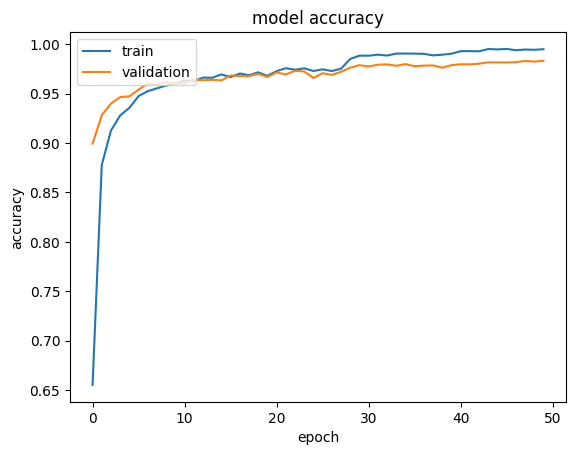

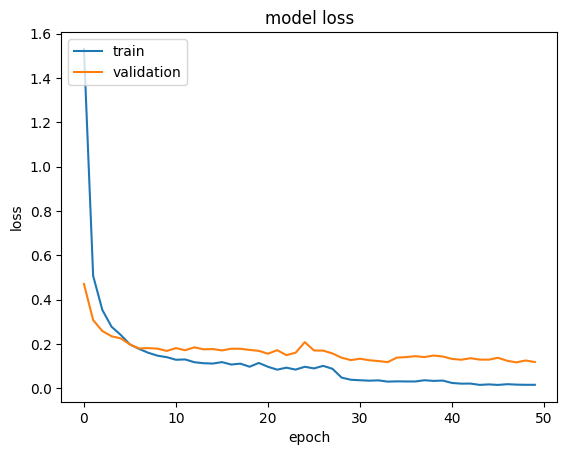

In [ ]:
print_accuracy_loss(history_CNN)

The plot shows the proccess of training and validation loss and accuracy of the model regards the number of epochs. As we can see the model reach excellent results both in the accuracy of validatio and training, infact after 30 epochs the accuracy is close to the 99%. Also the loss after approximately 10–15 epochs stabilize near 0.

In [ ]:
print_confusion_matrix_pandas(y_test_one_hot, y_pred)

The main diagonal represents the correct predictions for each class. Most of the intensity is along this line, indicating that the model correctly classifies most instances. Some subject like the 113 has very poor performance and this can be due to the fact that it has less test data as we can see in the graph below which shows the number of samples for each subject.

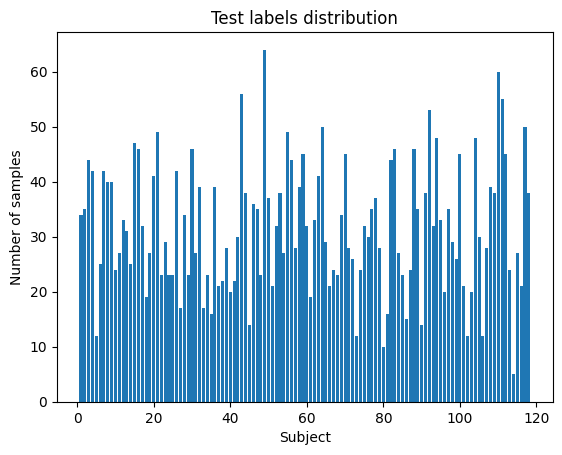

###Perturbate the data to verify the robustness of the model

In this function, we introduce Gaussian noise into the test data to evaluate the robustness of the CNN model for gait classification. The add_noise function generates random noise with a mean of 0 and a standard deviation defined by the noise_factor parameter, which simulates realistic perturbations in the input data. By adding this noise to the original test samples, we create a "perturbed" version of the dataset that challenges the model to maintain its classification performance under altered conditions.

In [ ]:
#Add noise to the data (parameter noise_factor: Standard deviation of the noise)
def add_noise(data, noise_factor=0.02):
    noise = np.random.normal(0, noise_factor, data.shape)
    return data + noise #Return the noisy data

In [ ]:
X_test_perturbated = add_noise(X_test)
model_CNN.evaluate(X_test_perturbated, y_test_one_hot)

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9377 - loss: 0.8352


[0.8607693910598755, 0.9339572191238403]

We introduce a small perturbation to the test data. The model achieves 93% accuracy on the perturbed test data, which is nearly the same accuracy as the original test. This indicates that the added noise does not impact the model's ability to correctly classify subjects so far.

In [ ]:
y_pred_noise = model_CNN.predict(X_test_perturbated)
get_f1_score(y_test_one_hot,y_pred_noise)
get_recall(y_test_one_hot, y_pred_noise)
get_precision(y_test_one_hot, y_pred_noise)

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
F1 score: 0.9184734466050201
Recall score: 0.9298518731716294
Precision score: 0.9283763841928627


0.9283763841928627

The good scores indicate that the model is still able to correctly classify the data with a small amount of noise.

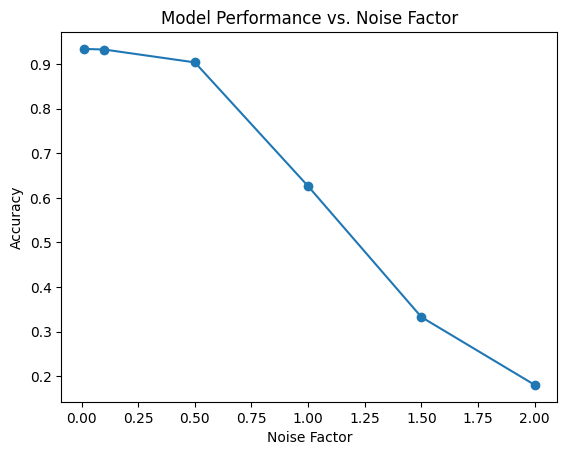

In [ ]:
noise_levels = [0.01, 0.1, 0.5, 1, 1.5, 2]
results = []

for noise_factor in noise_levels:
    X_test_perturbated = add_noise(X_test, noise_factor=noise_factor)
    loss, accuracy = model_CNN.evaluate(X_test_perturbated, y_test_one_hot, verbose=0)
    results.append({'noise_factor': noise_factor, 'loss': loss, 'accuracy': accuracy})

# Visualize results
import matplotlib.pyplot as plt
noise_factors = [r['noise_factor'] for r in results]
accuracies = [r['accuracy'] for r in results]

plt.plot(noise_factors, accuracies, marker='o')
plt.xlabel('Noise Factor')
plt.ylabel('Accuracy')
plt.title('Model Performance vs. Noise Factor')
plt.show()

By adding different levels of noise, it is possible to notice that with a noise_factor of 1 the performance drops rapidly, no longer being able to correctly distinguish the various subjects.

In [ ]:
!pip install visualkeras
import keras as k
from keras import models
from keras import layers
import visualkeras

#Print the architecture of the CNN
visualkeras.layered_view(model_CNN, legend=True, to_file="cnn_model_visualization.png").show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 9.5 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


##CNN+LSTM

This architecture combines CNN and LSTM layers to leverage the strengths of both models for gait classification. The CNN layers serve as feature extractors, identifying patterns in the input sequences. These layers are followed by LSTM units, which capture temporal dependencies of the sequence.

After feature extraction and temporal modeling, the architecture concludes with dense layers for classification across the 118 classes. Regularization techniques, such as dropout, are employed throughout to prevent overfitting. Additionally, a learning rate scheduler adjusts the training process dynamically to ensure efficient convergence.

###Create the model

In [ ]:
model_CNN_LSTM = Sequential([
    #Use CNN for feature extraction
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(128, 6)),
    MaxPooling1D(pool_size=2),
    Dropout(0.1),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.1),

    #LSTM for temporal dependency
    LSTM(units=64, return_sequences=False),

    #Last layers for classification
    Dense(units=128, activation='relu'),
    Dropout(0.25),
    Dense(units=118, activation='softmax')
])

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    verbose = 1,
    patience=5,
    mode='auto',
    min_lr=0.0001
)
model_CNN_LSTM.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_CNN_LSTM = model_CNN_LSTM.fit(X_train, y_train_one_hot, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[lr_scheduler, early_stopping])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 32s 131ms/step - accuracy: 0.1387 - loss: 3.8184 - val_accuracy: 0.6741 - val_loss: 1.3999 - learning_rate: 0.0010
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.6221 - loss: 1.3663 - val_accuracy: 0.8340 - val_loss: 0.6641 - learning_rate: 0.0010
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 43s 141ms/step - accuracy: 0.8005 - loss: 0.7387 - val_accuracy: 0.9062 - val_loss: 0.3970 - learning_rate: 0.0010
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 28s 129ms/step - accuracy: 0.8748 - loss: 0.4966 - val_accuracy: 0.9201 - val_loss: 0.3122 - learning_rate: 0.0010
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 41s 128ms/step - accuracy: 0.9111 - loss: 0.3510 - val_accuracy: 0.9352 - val_loss: 0.2728 - learning_rate: 0.0010
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 42s 133ms/step - accuracy: 0.9255 - loss: 0.3063 - val_accuracy: 0.9477 - val_loss: 0.2116 - learning_rate: 0.0010
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - accuracy: 0.9

###Evaluation of the model in the test_set

In [ ]:
test_loss, test_accuracy_CNN_LSTM = model_CNN_LSTM.evaluate(X_test, y_test_one_hot)

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9203 - loss: 0.7603


The CNN-LSTM model achieves good performance, with training accuracy reaching 99% and validation accuracy peaking at 98%, while the test accuracy is slightly lower at 92.09% indicating some overfitting in train and validation data even if we use some regularization techniques like dropout and dynamic learning rate adjustment. The result are similar to the ones of the CNN.

###Compute some metrics

In [ ]:
y_pred_CNN_LSTM = model_CNN_LSTM.predict(X_test)
f1_score_CNN_LSTM = get_f1_score(y_test_one_hot,y_pred_CNN_LSTM)
recall_score_CNN_LSTM = get_recall(y_test_one_hot, y_pred_CNN_LSTM)
precision_score_CNN_LSTM = get_precision(y_test_one_hot, y_pred_CNN_LSTM)

117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
F1 score: 0.9066121168564039
Recall score: 0.9175521427554997
Precision score: 0.9157717592286579


The CNN+LSTM model shows good classification capabilities with precision, recall and F1 score higher than 90%.

In [ ]:
add_results("CNN_LSTM", history_CNN_LSTM.history["accuracy"][-1], history_CNN_LSTM.history["val_accuracy"][-1], test_accuracy_CNN_LSTM, f1_score_CNN_LSTM, recall_score_CNN_LSTM, precision_score_CNN_LSTM)

In [ ]:
print_confusion_matrix_pandas(y_test_one_hot, y_pred_CNN_LSTM)

The confusion matrix indicates that the CNN+LSTM model has a very good classification ability. As we can see some subject like the 113 that the CNN wasn't able to classify correctly, here have a good score.
However, with respect to the previous CNN confusion matrix, we have more off-diagonal elements (misclassifications).

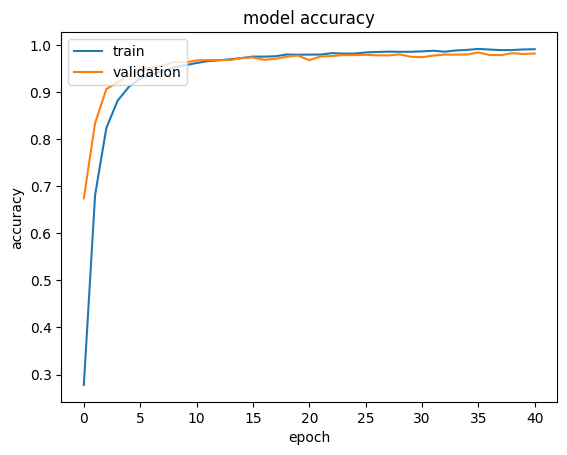

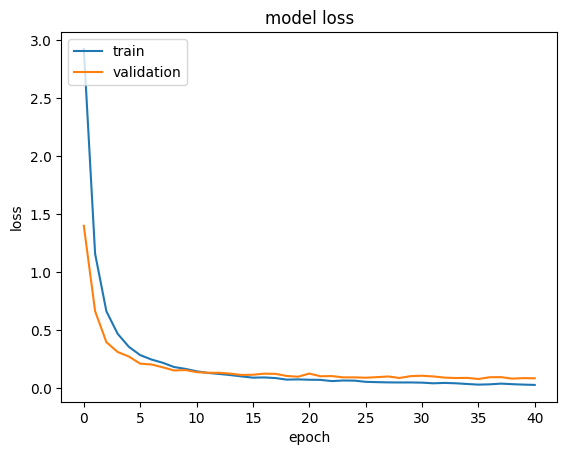

In [ ]:
print_accuracy_loss(history_CNN_LSTM)

As the CNN, we can see the model reach excellent results in accuracy of validation and training, infact after 10 epochs the accuracy are close to 99%, while the loss stabilizes near 0.

In [ ]:
visualkeras.layered_view(model_CNN_LSTM, legend=True, to_file="cnn_lstm_model_visualization.png").show()


/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


##RNN

This SimpleRNN-based architecture is designed for gait classification using sequential data from accelerometer and gyroscope signals. It leverages recurrent layers to capture temporal dependencies and dynamic relationships inherent in gait patterns.


 ### Simple RNN

In [ ]:
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.regularizers import l2

model_simple_RNN = Sequential([
    Input(shape=(128, 6)),
    SimpleRNN(64, activation='tanh', return_sequences=True, kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    SimpleRNN(32, activation='tanh', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(118, activation='softmax')
])
#Compile the model
model_simple_RNN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(
    monitor='val_accuracy',  #Monitor validation accuracy
    patience=10,          #Number of epochs to wait for improvement
    restore_best_weights=True,  #Restore the best weights after stopping
    verbose=1
)

#Train the model
history_simple_RNN = model_simple_RNN.fit(
    X_train,
    y_train_one_hot,
    validation_split=0.2,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[lr_scheduler, early_stopping]
)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.0738 - loss: 4.4357 - val_accuracy: 0.4188 - val_loss: 2.7403 - learning_rate: 0.0010
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.2763 - loss: 2.9504 - val_accuracy: 0.5540 - val_loss: 1.9363 - learning_rate: 0.0010
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 24s 113ms/step - accuracy: 0.3743 - loss: 2.4517 - val_accuracy: 0.6215 - val_loss: 1.6441 - learning_rate: 0.0010
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 39s 104ms/step - accuracy: 0.4275 - loss: 2.1985 - val_accuracy: 0.6562 - val_loss: 1.4419 - learning_rate: 0.0010
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.4669 - loss: 2.0403 - val_accuracy: 0.6898 - val_loss: 1.3264 - learning_rate: 0.0010
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 42s 111ms/step - accuracy: 0.4926 - loss: 1.9204 - val_accuracy: 0.7006 - val_loss: 1.2393 - learning_rate: 0.0010
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - accuracy: 0.5

In [ ]:
model_simple_RNN.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)             │ (None, 128, 64)             │           4,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 118)                 │          15,222 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 82,052 (320.52 KB)

 Trainable params: 27,286 (106.59 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 54,574 (213.18 KB)

In [ ]:
test_loss, test_accuracy_RNN = model_simple_RNN.evaluate(X_test, y_test_one_hot)

117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7755 - loss: 1.2989


####Simple RNN metrics

In [ ]:
y_pred_RNN = model_simple_RNN.predict(X_test)
f1_score_RNN = get_f1_score(y_test_one_hot,y_pred_RNN)
recall_score_RNN = get_recall(y_test_one_hot, y_pred_RNN)
precision_score_RNN = get_precision(y_test_one_hot, y_pred_RNN)

117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step
F1 score: 0.7160718139726248
Recall score: 0.7335815595598401
Precision score: 0.7596483716116808


The performance show that the model has some poor perfomance with respect to the previous results. The recall is moderately effective at identifying the true subject but may still miss some true positives. The precision score of 0.75 shows that the model is slightly better at avoiding false positives than capturing all true positives.

In [ ]:
print_confusion_matrix_pandas(y_test_one_hot, y_pred_RNN)

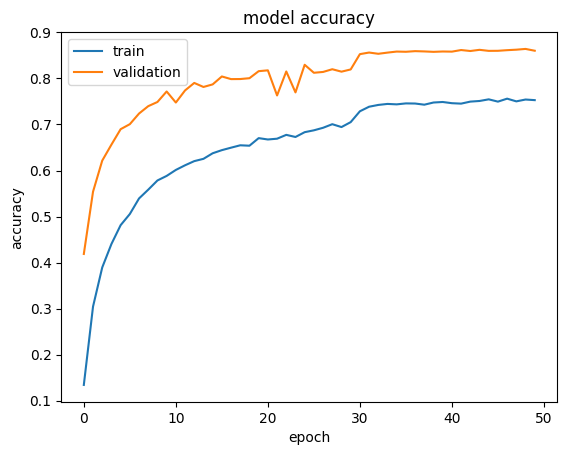

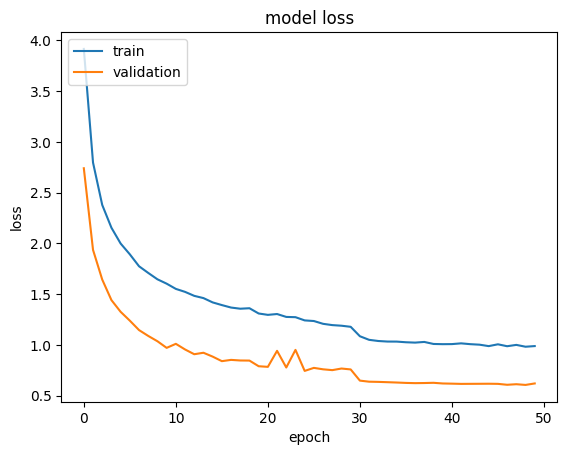

In [ ]:
print_accuracy_loss(history_simple_RNN)

The training accuracy stabilizes around 70%, indicating that the model is performing worse than the previous ones but showing on the other hand decent generalization results as can be seen from the accuracy on tests and validation.
Also the loss is higher with respect to the previous plots, infact after 30 epochs is near 0.5 for validation and 1 for training.

In [ ]:
add_results("RNN", history_simple_RNN.history["accuracy"][-1], history_simple_RNN.history["val_accuracy"][-1], test_accuracy_RNN, f1_score_RNN, recall_score_RNN, precision_score_RNN)

In [ ]:
visualkeras.layered_view(model_simple_RNN, legend=True, to_file="simple_rnn_model_visualization.png").show()

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


##LSTM

We now try to use a model with two stacked LSTM layers (64 and 32 units) to effectively capture the temporal dependencies and dynamic patterns in the input data and verify if the perfomance improves with respect to the previous RNN.

In [ ]:
# Costruzione del modello LSTM
model_LSTM = Sequential([
    Input(shape=(128, 6)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(118, activation='softmax')  #Use sigmoid for binary classification
    ])

# Compilazione del modello
model_LSTM.compile(
    optimizer=Adam(learning_rate=0.0025),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callback per migliorare il training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-4, verbose=1)


# Addestramento del modello
history_LSTM = model_LSTM.fit(
    X_train,
    y_train_one_hot,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 66s 290ms/step - accuracy: 0.1757 - loss: 3.5398 - val_accuracy: 0.6230 - val_loss: 1.3513 - learning_rate: 0.0025
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 81s 287ms/step - accuracy: 0.6146 - loss: 1.3316 - val_accuracy: 0.7876 - val_loss: 0.7718 - learning_rate: 0.0025
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 287ms/step - accuracy: 0.7543 - loss: 0.8933 - val_accuracy: 0.8731 - val_loss: 0.5209 - learning_rate: 0.0025
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 285ms/step - accuracy: 0.8363 - loss: 0.6281 - val_accuracy: 0.8802 - val_loss: 0.4385 - learning_rate: 0.0025
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 286ms/step - accuracy: 0.8538 - loss: 0.5486 - val_accuracy: 0.9038 - val_loss: 0.3738 - learning_rate: 0.0025
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 82s 286ms/step - accuracy: 0.8841 - loss: 0.4454 - val_accuracy: 0.9129 - val_loss: 0.3310 - learning_rate: 0.0025
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 67s 312ms/step - accuracy: 0.8

In [ ]:
model_LSTM.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 128, 64)             │          18,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_32 (Dropout)                 │ (None, 128, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_33 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 118)                 │           7,670 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,124 (473.14 KB)

 Trainable params: 40,374 (157.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 80,750 (315.43 KB)

In [ ]:
test_loss, test_accuracy_LSTM = model_LSTM.evaluate(X_test, y_test_one_hot)

117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9279 - loss: 0.7547


The model shows very high accuracy in training, validation and test. In this case too the test accuracy is slightly lower of the training and validation, suggesting again some overfitting.

In [ ]:
visualkeras.layered_view(model_LSTM, legend=True, to_file="lstm_model_visualization.png").show()

/usr/local/lib/python3.11/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


####LSTM metrics

In [ ]:
y_pred_LSTM = model_LSTM.predict(X_test)
f1_score_LSTM = get_f1_score(y_test_one_hot,y_pred_LSTM)
recall_score_LSTM = get_recall(y_test_one_hot, y_pred_LSTM)
precision_score_LSTM = get_precision(y_test_one_hot, y_pred_LSTM)

117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step
F1 score: 0.904576714044076
Recall score: 0.9148834031491757
Precision score: 0.9132892280516798


The model demonstrates excellent performance with an F1 score of 0.905, indicating a strong balance between precision (0.913) and recall (0.915), reflecting high accuracy and reliability in predictions with minimal false positives and false negatives.

In [ ]:
add_results("LSTM", history_LSTM.history["accuracy"][-1], history_LSTM.history["val_accuracy"][-1], test_accuracy_LSTM, f1_score_LSTM, recall_score_LSTM, precision_score_LSTM)

In [ ]:
print_confusion_matrix_pandas(y_test_one_hot, y_pred_LSTM)

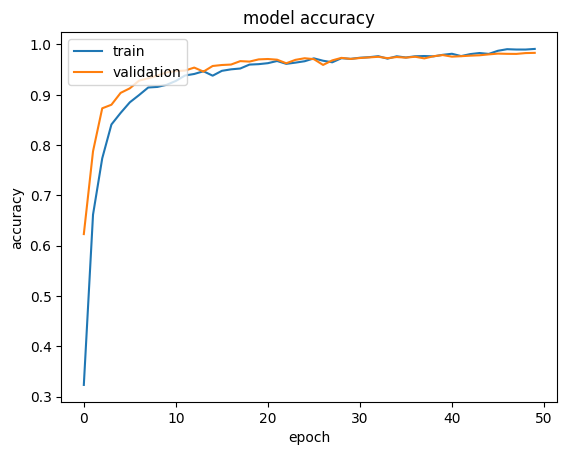

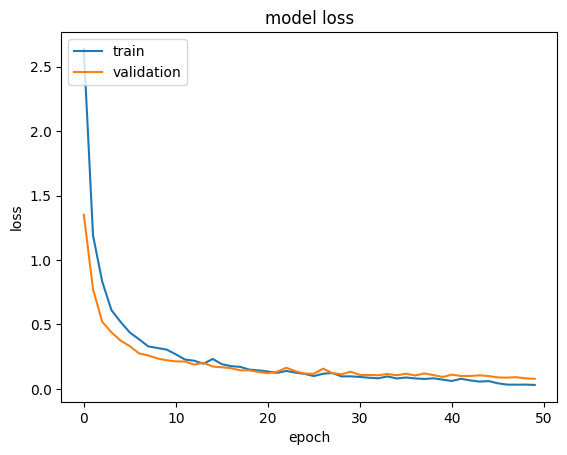

In [ ]:
print_accuracy_loss(history_LSTM)

The model has very good performance, but as we can see in the confusion matrix, there seem to be slightly more off-diagonal elements than in the CNN confusion matrix. This suggests that the CNN is more effective at capturing patterns in this dataset and correctly classify the different subjects.

##GRU

The GRU is similar to an LSTM in that it uses a gating mechanism to control the input and forgetting of features, but it differs by omitting the context vector and output gate, which reduces the number of parameters compared to an LSTM.

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Input, Dropout

model_GRU = Sequential([
    Input(shape=(128, 6)),
    GRU(128, return_sequences=True),
    Dropout(0.3),
    GRU(64),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(118, activation='softmax')
])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-4, verbose=1)

model_GRU.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_GRU.summary()
history_GRU = model_GRU.fit(
    X_train,
    y_train_one_hot,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping, reduce_lr]
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                          │ (None, 128, 128)            │          52,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_5 (GRU)                          │ (None, 64)                  │          37,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 118)                 │          15,222 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 113,014 (441.46 KB)

 Trainable params: 113,014 (441.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 140s 644ms/step - accuracy: 0.1600 - loss: 3.7742 - val_accuracy: 0.6671 - val_loss: 1.4058 - learning_rate: 0.0010
Epoch 2/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 133s 644ms/step - accuracy: 0.5773 - loss: 1.5446 - val_accuracy: 0.8101 - val_loss: 0.7997 - learning_rate: 0.0010
Epoch 3/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 140s 635ms/step - accuracy: 0.7520 - loss: 0.9705 - val_accuracy: 0.8630 - val_loss: 0.5433 - learning_rate: 0.0010
Epoch 4/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 158s 715ms/step - accuracy: 0.8264 - loss: 0.6838 - val_accuracy: 0.9021 - val_loss: 0.3866 - learning_rate: 0.0010
Epoch 5/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 189s 652ms/step - accuracy: 0.8715 - loss: 0.5232 - val_accuracy: 0.9157 - val_loss: 0.3188 - learning_rate: 0.0010
Epoch 6/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 140s 643ms/step - accuracy: 0.8965 - loss: 0.4192 - val_accuracy: 0.9263 - val_loss: 0.2853 - learning_rate: 0.0010
Epoch 7/20
207/207 ━━━━━━━━━━━━━━━━━━━━ 141s 638ms/step - accura

In [ ]:
test_loss, test_accuracy_GRU = model_GRU.evaluate(X_test, y_test_one_hot)

117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.8993 - loss: 0.8253


GRU performed well in training and validation, but in the test set the accuracy drops to 89%, leading to a worse test accuracy than CNN and LSTM.

In [ ]:
y_pred_GRU = model_GRU.predict(X_test)
f1_score_GRU = get_f1_score(y_test_one_hot,y_pred_GRU)
recall_score_GRU = get_recall(y_test_one_hot, y_pred_GRU)
precision_score_GRU = get_precision(y_test_one_hot, y_pred_GRU)

117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step
F1 score: 0.8817380054631105
Recall score: 0.8910449747986942
Precision score: 0.8932997994856579


The GRU model demonstrates very good performance with high precision, recall, and F1 score.

In [ ]:
print_confusion_matrix_pandas(y_test_one_hot, y_pred_GRU)

Similar to the CNN, the GRU confusion matrix shows strong diagonal dominance, indicating a high number of correctly classified instances across most classes.
There are fewer misclassifications (off-diagonal elements) compared to the LSTM, suggesting better performance in terms of class distinction.


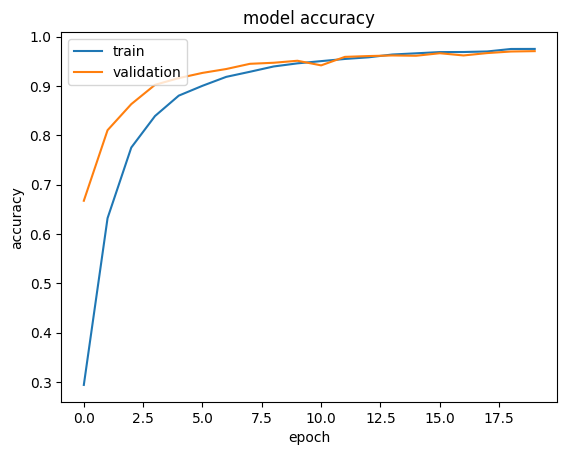

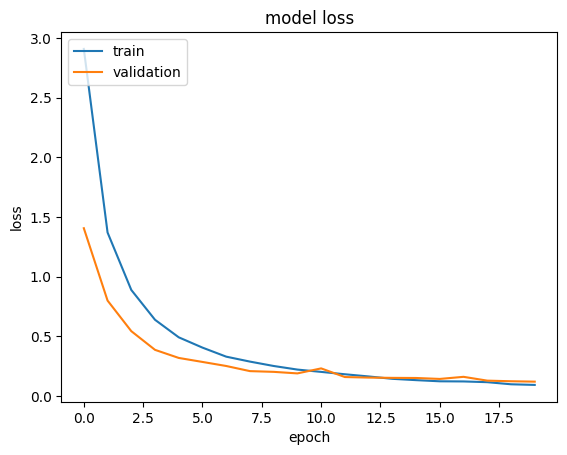

In [ ]:
print_accuracy_loss(history_GRU)

The plots show excellent performance of the GRU model. Both training and validation loss decrease steadily, converging around epoch 10, with validation loss initially lower than training loss, indicating good generalization and no overfitting. Similarly, training and validation accuracy increase rapidly during the early epochs, surpassing 90% around epochs 7 and stabilizing near 97%, demonstrating that the model effectively learns the patterns in the dataset.

In [ ]:
add_results("GRU", history_GRU.history["accuracy"][-1], history_GRU.history["val_accuracy"][-1], test_accuracy_GRU, f1_score_GRU, recall_score_GRU, precision_score_GRU)

In [ ]:
visualkeras.layered_view(model_GRU, legend=True, to_file="simple_gru_visualization.png").show()

##Feature extraction using CNN and SVM

We try now to take the output of the flatten layer of the initial CNN. So, we're using the CNN as feature extractor and then, with a SVM, we try to classify the different subjects.

In [ ]:
from tensorflow.keras.models import Model

#Create the model with input and output defined
feature_extractor_conv = Model(inputs=model_CNN.inputs, outputs=[layer.output for layer in model_CNN.layers])

#Extract output of each layer
features_conv_X_test = feature_extractor_conv(X_test)
features_conv_X_train = feature_extractor_conv(X_train)


In [ ]:
flatten_features_X_train = features_conv_X_train[-2]  #Extract feature from flatten layer
flatten_features_X_test = features_conv_X_test[-2]  #Extract feature from flatten layer
X_train_val_svm = flatten_features_X_train.numpy().reshape(flatten_features_X_train.shape[0], -1)  #(n_samples, n_features)
X_test_svm = flatten_features_X_test.numpy().reshape(flatten_features_X_test.shape[0], -1)

X_train_svm, X_val_svm, y_train_svm, y_val_svm = train_test_split(X_train_val_svm, y_train, test_size=0.2, random_state=2)

In [ ]:
scaler = StandardScaler().fit(X_train_svm)
#use the scaler parameter to transform applying the standardization
X_train_svm_scaled = scaler.transform(X_train_svm)
X_val_svm_scaled = scaler.transform(X_val_svm)
X_test_svm_scaled = scaler.transform(X_test_svm)
X_train_val_svm_scaled = scaler.transform(X_train_val_svm)

###Perform K-Fold Cross-Validation to choose the best hyperparameters.

In [ ]:
#find the optimal combination of hyperparameters for SVM model in order to have the best performance
#selecting the highest average score
def k_fold_cross_validation(X, Y, num_folds = 5, **param_grid):

    # Grid of hyperparams into list
    param_keys = list(param_grid.keys())
    param_values = list(param_grid.values())

    # Generate Cartesian product of values
    combinations = product(*param_values)

    # Create a list of dictionaries from combinations
    param_list = [dict(zip(param_keys, combination)) for combination in combinations]

    kFold = KFold(n_splits = num_folds, shuffle = True, random_state = 2)
    best_score = -1
    best_param = None

    for params in param_list:
      print("K-FOLD for parameter ",params)
      modelSVM = svm.SVC(**params)

      scores = []
      for train_idx, val_idx in kFold.split((X)):
        X_train_kfold, X_val_kfold = X[train_idx], X[val_idx]
        Y_train_kfold, Y_val_kfold = Y[train_idx], Y[val_idx]

        scaler_kFold = preprocessing.StandardScaler().fit(X_train_kfold)
        X_train_kfold_scaled = scaler_kFold.transform(X_train_kfold)
        X_val_kfold_scaled = scaler_kFold.transform(X_val_kfold)

        modelSVM.fit(X_train_kfold_scaled, Y_train_kfold)
        score = modelSVM.score(X_val_kfold_scaled, Y_val_kfold)
        scores.append(score)

      mean = np.mean(scores)
      if mean > best_score:
        best_score = mean
        best_param = params

    return best_param

LINEAR

In [ ]:
#find the best hyperparameters for a Linear SVM model using k-fold cross validation

print("\nLinear SVM:")

param_grid = {
    'kernel': ['linear'],     # Linear kernel
    'C': [0.1, 1, 10]    # regularization coefficient
}
linear_optimal_param = k_fold_cross_validation(X = X_train_svm_scaled, Y = y_train_svm, **param_grid)

print("\nBest value for hyperparameters: ", linear_optimal_param)



Linear SVM:
K-FOLD for parameter  {'kernel': 'linear', 'C': 0.1}
K-FOLD for parameter  {'kernel': 'linear', 'C': 1}
K-FOLD for parameter  {'kernel': 'linear', 'C': 10}

Best value for hyperparameters:  {'kernel': 'linear', 'C': 1}


In [ ]:
# retrain the SVM based on the best parameters received from the k-fold cross validation and calculate the accuracy

final_model_linear = svm.SVC(**linear_optimal_param)
final_model_linear.fit(X_train_svm_scaled, y_train_svm)
training_score_linear = final_model_linear.score(X_train_svm_scaled, y_train_svm)

print("\nTraining score:", training_score_linear)



Training score: 0.9998111996375033


POLY

In [ ]:
#find the best hyperparameters for a Polynomial SVM model using k-fold cross validation

print("\nPoly SVM")

param_grid = {
    'kernel': ['poly'],       #Polynomial kernel
    'C': [0.1, 1, 10],   #Regularization coefficient
    'degree': [2, 3, 4]       #specifies the highest power of the polynomial
}
poly_optimal_param = k_fold_cross_validation(X = X_train_svm_scaled, Y = y_train_svm, **param_grid)

print("\nBest value for hyperparameters: ", poly_optimal_param)


Poly SVM
K-FOLD for parameter  {'kernel': 'poly', 'C': 0.1, 'degree': 2}
K-FOLD for parameter  {'kernel': 'poly', 'C': 0.1, 'degree': 3}
K-FOLD for parameter  {'kernel': 'poly', 'C': 0.1, 'degree': 4}
K-FOLD for parameter  {'kernel': 'poly', 'C': 1, 'degree': 2}
K-FOLD for parameter  {'kernel': 'poly', 'C': 1, 'degree': 3}
K-FOLD for parameter  {'kernel': 'poly', 'C': 1, 'degree': 4}
K-FOLD for parameter  {'kernel': 'poly', 'C': 10, 'degree': 2}
K-FOLD for parameter  {'kernel': 'poly', 'C': 10, 'degree': 3}
K-FOLD for parameter  {'kernel': 'poly', 'C': 10, 'degree': 4}

Best value for hyperparameters:  {'kernel': 'poly', 'C': 10, 'degree': 2}


In [ ]:
# retrain the SVM based on the best parameters received from the k-fold cross validation and calculate the accuracy

final_model_poly = svm.SVC(**poly_optimal_param)
final_model_poly.fit(X_train_svm_scaled, y_train_svm)
training_score_poly = final_model_poly.score(X_train_svm_scaled, y_train_svm)

print("\nTraining score:", training_score_poly)


Training score: 0.9987161575350225


RBF

In [ ]:
#Find the best hyperparameters for a Radial Basis Function SVM model using k-fold cross validation

print("\nRBF SVM")

param_grid = {
    'kernel': ['rbf'],              #Radial Basis Function kernel
    'C': [0.1, 1, 10],              #Regularization parameter
    'gamma': [0.01, 0.03, 0.05],    #kernel coefficient gamma: influence the shape of the decision boundary
}
rbf_optimal_param = k_fold_cross_validation(X = X_train_svm_scaled, Y = y_train_svm, **param_grid)

print("\nBest value for hyperparameters: ", rbf_optimal_param)


RBF SVM
K-FOLD for parameter  {'kernel': 'rbf', 'C': 0.1, 'gamma': 0.01}
K-FOLD for parameter  {'kernel': 'rbf', 'C': 0.1, 'gamma': 0.03}
K-FOLD for parameter  {'kernel': 'rbf', 'C': 0.1, 'gamma': 0.05}
K-FOLD for parameter  {'kernel': 'rbf', 'C': 1, 'gamma': 0.01}
K-FOLD for parameter  {'kernel': 'rbf', 'C': 1, 'gamma': 0.03}
K-FOLD for parameter  {'kernel': 'rbf', 'C': 1, 'gamma': 0.05}
K-FOLD for parameter  {'kernel': 'rbf', 'C': 10, 'gamma': 0.01}
K-FOLD for parameter  {'kernel': 'rbf', 'C': 10, 'gamma': 0.03}
K-FOLD for parameter  {'kernel': 'rbf', 'C': 10, 'gamma': 0.05}

Best value for hyperparameters:  {'kernel': 'rbf', 'C': 10, 'gamma': 0.01}


In [ ]:
#Retrain the SVM based on the best parameters received from the k-fold cross validation and calculate the accuracy

final_model_rbf = svm.SVC(**rbf_optimal_param)
final_model_rbf.fit(X_train_svm_scaled, y_train_svm)
training_score_rbf = final_model_rbf.score(X_train_svm_scaled, y_train_svm)

print("\nTraining score:", training_score_rbf)


Training score: 0.9996223992750066


SIGMOID

In [ ]:
#Find the best hyperparameters for a Radial Basis Function SVM model using k-fold cross validation

print("\nSigmoid SVM")

param_grid = {
    'kernel': ['sigmoid'],    #Sigmoid kernel
    'C': [0.1, 1, 10],        #regularization coefficient
    'gamma': [0.01, 0.05],    #kernel coefficient gamma: defines how far the influence of a single training example reaches
    'coef0': [0, 1],          #acts as a bias term: it shifts the decision boundary of the SVM and can influence the model's performance
}
sigmoid_optimal_param = k_fold_cross_validation(X = X_train_svm_scaled, Y = y_train_svm, **param_grid)

print("\nBest value for hyperparameters: ", sigmoid_optimal_param)


Sigmoid SVM
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 0.1, 'gamma': 0.01, 'coef0': 0}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 0.1, 'gamma': 0.01, 'coef0': 1}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 0.1, 'gamma': 0.05, 'coef0': 0}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 0.1, 'gamma': 0.05, 'coef0': 1}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 1, 'gamma': 0.01, 'coef0': 0}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 1, 'gamma': 0.01, 'coef0': 1}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 1, 'gamma': 0.05, 'coef0': 0}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 1, 'gamma': 0.05, 'coef0': 1}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 10, 'gamma': 0.01, 'coef0': 0}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 10, 'gamma': 0.01, 'coef0': 1}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 10, 'gamma': 0.05, 'coef0': 0}
K-FOLD for parameter  {'kernel': 'sigmoid', 'C': 10, 'gamma': 0.05, 'coef0': 1}

Best value for hyperparame

In [ ]:
#Retrain the SVM based on the best parameters received from the k-fold cross validation and calculate the accuracy

final_model_sigmoid = svm.SVC(**sigmoid_optimal_param)
final_model_sigmoid.fit(X_train_svm_scaled, y_train_svm)
training_score_sigmoid = final_model_sigmoid.score(X_train_svm_scaled, y_train_svm)

print("\nTraining score:", training_score_sigmoid)


Training score: 0.9723596269304837


In [ ]:
print("\nVALIDATION TO CHOOSE SVM KERNEL:")

#Use the validation set to choose the best kernel

dictionary = []
val_score_linear = final_model_linear.score(X_val_svm, y_val_svm)
dictionary.append((final_model_linear,val_score_linear))
val_score_poly = final_model_poly.score(X_val_svm, y_val_svm)
dictionary.append((final_model_poly,val_score_poly))
val_score_rbf = final_model_rbf.score(X_val_svm, y_val_svm)
dictionary.append((final_model_rbf,val_score_rbf))
val_score_sigmoid = final_model_sigmoid.score(X_val_svm, y_val_svm)
dictionary.append((final_model_sigmoid,val_score_sigmoid))

best_kernel = None
best_score = float('-inf')

for kernel, score in dictionary:
  print(f'{kernel} validation score: {score}')
  if score > best_score:
        best_score = score
        best_kernel = kernel

print("\n---\nBest kernel: ", best_kernel)
print("Validation score of best kernel: ", best_score)


VALIDATION TO CHOOSE SVM KERNEL:
SVC(C=1, kernel='linear') validation score: 0.9565020389669234
SVC(C=10, degree=2, kernel='poly') validation score: 0.9447213411871318
SVC(C=10, gamma=0.01) validation score: 0.006041383476816191
SVC(C=1, coef0=0, gamma=0.01, kernel='sigmoid') validation score: 0.1298897447515481

---
Best kernel:  SVC(C=1, kernel='linear')
Validation score of best kernel:  0.9565020389669234


The results show good performance with poly and linear kernel, while they drop with sigmoid and RBF, indicating very poor generalization for them.

In [ ]:
print("\nBEST MODEL:")

best_model_parameter = None
if best_kernel.kernel == 'linear':
  best_model_parameter = linear_optimal_param
elif best_kernel.kernel == 'poly':
  best_model_parameter = poly_optimal_param
elif best_kernel.kernel == 'rbf':
  best_model_parameter = rbf_optimal_param
elif best_kernel.kernel == 'sigmoid':
  best_model_parameter = sigmoid_optimal_param

#retrain the svm with the best kernel and parameter, fitting the X_train_val set

svm_best_model = svm.SVC( **best_model_parameter)
svm_best_model.fit(X_train_val_svm_scaled, y_train)
score_best_model = svm_best_model.score(X_train_val_svm_scaled, y_train)

print("Best model hyperparameters:", best_model_parameter)
print("Score of the best model: ",score_best_model)


BEST MODEL:
Best model hyperparameters: {'kernel': 'linear', 'C': 1}
Score of the best model:  0.999879168680522


In [ ]:
print("\nGENERALIZATION SCORE BEST MODEL:")
#calculate the generalization score
generalization_score =  svm_best_model.score(X_test_svm_scaled, y_test)
print("Estimate of the generalization score for best SVM model: ", generalization_score)
print("Number of support vectors: ", svm_best_model.support_vectors_.shape[0])


GENERALIZATION SCORE BEST MODEL:
Estimate of the generalization score for best SVM model:  0.9299465240641711
Number of support vectors:  6253


The best SVM model achieves a generalization score of 0.9299, with 6253 support vectors. While the model fits the training and validation data very well, achieving a score of 0.99, the 6% drop in performance on unseen data suggests some overfitting. This overfitting is further indicated by the large number of support vectors, implying the model relies heavily on specific training data to define its decision boundaries.

In [ ]:
#compute
print("\nSVM result")
y_predicted_svm = svm_best_model.predict(X_test_svm_scaled)

f1_svm = f1_score(y_test, y_predicted_svm, average='macro')
recall_svm = recall_score(y_test, y_predicted_svm, average='macro')
precision_svm = precision_score(y_test, y_predicted_svm, average='macro')
print(f"F1 Score: {f1_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")



SVM result
F1 Score: 0.9108
Recall: 0.9232
Precision: 0.9179


The scores indicate that the SVM has very good performance in finding true positive and also a good balance between precision and recall as we can see from F1 Score.

In [ ]:
conf_matrix = confusion_matrix(y_test, y_predicted_svm)

conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(118, 118))
sns.heatmap(conf_matrix_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

As for the CNN confusion matrix, the intensity is along the diagonal, indicating very good performance, but with a few more elements off-diagonal than the CNN.

In [ ]:
add_results("CNN SVM", score_best_model, None, generalization_score, f1_svm, recall_svm, precision_svm)

#Print statistics of the different models

In [ ]:
#print results of the different models
print(results_df)

      model  train accuracy  validation accuracy  accuracy    recall  \
0       CNN        0.994978             0.983235  0.934225  0.918524   
1  CNN_LSTM        0.990673             0.981574  0.921658  0.906612   
2       RNN        0.752860             0.860142  0.770053  0.716072   
3      LSTM        0.991202             0.983386  0.922460  0.904577   
4   CNN SVM        0.999879                  NaN  0.929947  0.910790   
5       GRU        0.974890             0.970397  0.902674  0.891045   

   F1 Score  precision  
0  0.929929   0.927974  
1  0.917552   0.915772  
2  0.733582   0.759648  
3  0.914883   0.913289  
4  0.923173   0.917919  
5  0.881738   0.893300  


The results indicate that the CNN achieves the best overall performance, with high training and validation accuracy and strong precision, recall, and F1 scores. The CNN-SVM hybrid model performs slightly below the CNN but still demonstrates competitive metrics, especially in precision and F1 score. The GRU model performs well but slightly lags behind CNN-based models in accuracy, F1 score and recall. The LSTM and CNN-LSTM models show comparable results, both offering robust performance, but the CNN outperforms them slightly. The RNN, however, struggles significantly compared to other architectures, with lower accuracy and F1 scores, indicating it may not be well-suited for this dataset. Overall, CNN-based approaches are the most effective, with GRU and LSTM as good alternatives.